# CineIQ: Content-Based Filtering Engine

**Objective:** To build a content-based recommendation engine that solves the "Cold Start" problem for new users. By analyzing the fundamental DNA of a movie—its plot, genres, cast, and crew—this model recommends visually and thematically similar films without relying on historical user rating data.

**Technical Approach:**
* **Metadata Fusion:** Merging TMDB movie metadata, credits, and keywords into a unified "metadata soup."
* **Natural Language Processing (NLP):** Utilizing a `TfidfVectorizer` (with bigrams and stop-word removal) to map text data into a high-dimensional mathematical space.
* **Similarity Scoring:** Computing a Cosine Similarity matrix to instantly identify the nearest neighbors for any given movie.
* **Pipeline Integration:** Exporting the vectorized matrices and mappings to `CineIQ/artifacts/` for seamless deployment to the FastAPI backend.

## 1. Environment Setup & Imports

In [1]:

import ast
import os
import re
import logging
import warnings
from typing import List, Optional, Dict, Any, Tuple
from difflib import get_close_matches
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity, linear_kernel
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from ast import literal_eval
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 20)
pd.set_option('display.max_colwidth', 60)
pd.set_option('display.width', 120)

logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s | %(levelname)-8s | %(message)s',
    datefmt='%H:%M:%S'
)
logger = logging.getLogger('CineIQ_ContentFilter')
logger.info('All libraries imported successfully.')

16:45:34 | INFO     | All libraries imported successfully.


## 2. Configuration & Constants

In [2]:
DATA_DIR = '../data'  
ARTIFACT_DIR = '../artifacts'

#TF-IDF Hyperparameters
TFIDF_MAX_FEATURES = 20_000
TFIDF_NGRAM_RANGE = (1, 2)
TFIDF_MIN_DF = 2
TFIDF_STOP_WORDS = 'english'

#Recommendation Defaults
DEFAULT_TOP_N = 10
TOP_CAST_COUNT = 3

os.makedirs(ARTIFACT_DIR, exist_ok=True)
logger.info(f'Artifact directory ready: {ARTIFACT_DIR}')

16:45:34 | INFO     | Artifact directory ready: ../artifacts


## 3. Data Loading

In [3]:
def load_csv(filename: str, low_memory: bool = False) -> pd.DataFrame:
    """Load a CSV file, trying .csv.zip then .csv."""
    zip_path = os.path.join(DATA_DIR, f'{filename}.zip')
    csv_path = os.path.join(DATA_DIR, filename)
    if os.path.exists(zip_path):
        logger.info(f'Loading {zip_path}')
        return pd.read_csv(zip_path, low_memory=low_memory)
    elif os.path.exists(csv_path):
        logger.info(f'Loading {csv_path}')
        return pd.read_csv(csv_path, low_memory=low_memory)
    else:
        raise FileNotFoundError(f'Neither {zip_path} nor {csv_path} found.')

df_meta = load_csv('movies_metadata.csv', low_memory=True)
df_credits = load_csv('credits.csv')
df_keywords = load_csv('keywords.csv')

print(f'movies_metadata : {df_meta.shape}')
print(f'credits         : {df_credits.shape}')
print(f'keywords        : {df_keywords.shape}')

16:45:34 | INFO     | Loading ../data\movies_metadata.csv
16:45:34 | INFO     | Loading ../data\credits.csv
16:45:35 | INFO     | Loading ../data\keywords.csv


movies_metadata : (45466, 24)
credits         : (45476, 3)
keywords        : (46419, 2)


## 4. Initial Data Inspection

In [4]:
print('movies_metadata — first 3 rows')
display(df_meta.head(3))
print(f'\nNull counts:\n{df_meta.isnull().sum()[df_meta.isnull().sum() > 0]}')

movies_metadata — first 3 rows


,adult,belongs_to_collection,budget,genres,homepage,id,imdb_id,original_language,original_title,overview,...,release_date,revenue,runtime,spoken_languages,status,tagline,title,video,vote_average,vote_count
0,False,"{'id': 10194, 'name': 'Toy Story Collection', 'poster_pa...",30000000,"[{'id': 16, 'name': 'Animation'}, {'id': 35, 'name': 'Co...",http://toystory.disney.com/toy-story,862,tt0114709,en,Toy Story,"Led by Woody, Andy's toys live happily in his room until...",...,1995-10-30,373554033.0,81.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,NaN,Toy Story,False,7.7,5415.0
1,False,NaN,65000000,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, 'name': 'Fa...",NaN,8844,tt0113497,en,Jumanji,When siblings Judy and Peter discover an enchanted board...,...,1995-12-15,262797249.0,104.0,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso_639_1': '...",Released,Roll the dice and unleash the excitement!,Jumanji,False,6.9,2413.0
2,False,"{'id': 119050, 'name': 'Grumpy Old Men Collection', 'pos...",0,"[{'id': 10749, 'name': 'Romance'}, {'id': 35, 'name': 'C...",NaN,15602,tt0113228,en,Grumpier Old Men,A family wedding reignites the ancient feud between next...,...,1995-12-22,0.0,101.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Still Yelling. Still Fighting. Still Ready for Love.,Grumpier Old Men,False,6.5,92.0



Null counts:
belongs_to_collection    40972
homepage                 37684
imdb_id                     17
original_language           11
overview                   954
popularity                   5
poster_path                386
production_companies         3
production_countries         3
release_date                87
revenue                      6
runtime                    263
spoken_languages             6
status                      87
tagline                  25054
title                        6
video                        6
vote_average                 6
vote_count                   6
dtype: int64


In [5]:
print('credits — first 2 rows')
display(df_credits.head(2))
print(f'\nkeywords — first 2 rows')
display(df_keywords.head(2))

credits — first 2 rows


,cast,crew,id
0,"[{'cast_id': 14, 'character': 'Woody (voice)', 'credit_i...","[{'credit_id': '52fe4284c3a36847f8024f49', 'department':...",862
1,"[{'cast_id': 1, 'character': 'Alan Parrish', 'credit_id'...","[{'credit_id': '52fe44bfc3a36847f80a7cd1', 'department':...",8844



keywords — first 2 rows


,id,keywords
0,862,"[{'id': 931, 'name': 'jealousy'}, {'id': 4290, 'name': '..."
1,8844,"[{'id': 10090, 'name': 'board game'}, {'id': 10941, 'nam..."


## 5. Data Preprocessing & Cleaning

### 5.1 Clean movies_metadata

In [6]:
# Keeping only relevant columns
META_COLS = ['id', 'title', 'overview', 'genres', 'vote_average',
             'vote_count', 'popularity', 'release_date']
df_meta = df_meta[META_COLS].copy()

# Removing rows where id is not numeric (corrupted rows)
df_meta['id'] = pd.to_numeric(df_meta['id'], errors='coerce')
rows_before = len(df_meta)
df_meta.dropna(subset=['id'], inplace=True)
df_meta['id'] = df_meta['id'].astype(int)
logger.info(f'Dropped {rows_before - len(df_meta)} rows with non-numeric id.')

df_meta.dropna(subset=['title'], inplace=True)
df_meta.drop_duplicates(subset='id', keep='first', inplace=True)
df_meta['overview'] = df_meta['overview'].fillna('')

df_meta['year'] = pd.to_datetime(df_meta['release_date'], errors='coerce').dt.year
df_meta['year'] = df_meta['year'].fillna(0).astype(int)

df_meta['popularity'] = pd.to_numeric(df_meta['popularity'], errors='coerce').fillna(0.0)
df_meta['vote_average'] = pd.to_numeric(df_meta['vote_average'], errors='coerce').fillna(0.0)
df_meta['vote_count'] = pd.to_numeric(df_meta['vote_count'], errors='coerce').fillna(0).astype(int)

print(f'Cleaned movies_metadata shape: {df_meta.shape}')
display(df_meta.head(3))

16:45:35 | INFO     | Dropped 3 rows with non-numeric id.


Cleaned movies_metadata shape: (45430, 9)


,id,title,overview,genres,vote_average,vote_count,popularity,release_date,year
0,862,Toy Story,"Led by Woody, Andy's toys live happily in his room until...","[{'id': 16, 'name': 'Animation'}, {'id': 35, 'name': 'Co...",7.7,5415,21.946943,1995-10-30,1995
1,8844,Jumanji,When siblings Judy and Peter discover an enchanted board...,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, 'name': 'Fa...",6.9,2413,17.015539,1995-12-15,1995
2,15602,Grumpier Old Men,A family wedding reignites the ancient feud between next...,"[{'id': 10749, 'name': 'Romance'}, {'id': 35, 'name': 'C...",6.5,92,11.712900,1995-12-22,1995


### 5.2 Clean credits & keywords

In [7]:
# Ensuring id columns are int
df_credits['id'] = pd.to_numeric(df_credits['id'], errors='coerce')
df_credits.dropna(subset=['id'], inplace=True)
df_credits['id'] = df_credits['id'].astype(int)

df_keywords['id'] = pd.to_numeric(df_keywords['id'], errors='coerce')
df_keywords.dropna(subset=['id'], inplace=True)
df_keywords['id'] = df_keywords['id'].astype(int)

logger.info(f'credits shape: {df_credits.shape}, keywords shape: {df_keywords.shape}')

16:45:36 | INFO     | credits shape: (45476, 3), keywords shape: (46419, 2)


### 5.3 Merging Datasets

In [8]:
df = df_meta.merge(df_credits, on='id', how='left')
df = df.merge(df_keywords, on='id', how='left')

logger.info(f'Merged dataset shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
display(df.head(3))

16:45:36 | INFO     | Merged dataset shape: (46493, 12)


Columns: ['id', 'title', 'overview', 'genres', 'vote_average', 'vote_count', 'popularity', 'release_date', 'year', 'cast', 'crew', 'keywords']


,id,title,overview,genres,vote_average,vote_count,popularity,release_date,year,cast,crew,keywords
0,862,Toy Story,"Led by Woody, Andy's toys live happily in his room until...","[{'id': 16, 'name': 'Animation'}, {'id': 35, 'name': 'Co...",7.7,5415,21.946943,1995-10-30,1995,"[{'cast_id': 14, 'character': 'Woody (voice)', 'credit_i...","[{'credit_id': '52fe4284c3a36847f8024f49', 'department':...","[{'id': 931, 'name': 'jealousy'}, {'id': 4290, 'name': '..."
1,8844,Jumanji,When siblings Judy and Peter discover an enchanted board...,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, 'name': 'Fa...",6.9,2413,17.015539,1995-12-15,1995,"[{'cast_id': 1, 'character': 'Alan Parrish', 'credit_id'...","[{'credit_id': '52fe44bfc3a36847f80a7cd1', 'department':...","[{'id': 10090, 'name': 'board game'}, {'id': 10941, 'nam..."
2,15602,Grumpier Old Men,A family wedding reignites the ancient feud between next...,"[{'id': 10749, 'name': 'Romance'}, {'id': 35, 'name': 'C...",6.5,92,11.712900,1995-12-22,1995,"[{'cast_id': 2, 'character': 'Max Goldman', 'credit_id':...","[{'credit_id': '52fe466a9251416c75077a89', 'department':...","[{'id': 1495, 'name': 'fishing'}, {'id': 12392, 'name': ..."


## 6. Exploratory Data Analysis (EDA) for Content Metadata
Before vectorizing our text data, we need to understand the distribution and quality of our metadata. In the TMDB dataset, features like `genres` and `production_companies` are stored as stringified JSON dictionaries. 

This setup block safely unpacks those JSON strings into clean Python lists so we can analyze the underlying themes of our dataset.

In [9]:
sns.set_theme(style="darkgrid", palette="magma")
# Helper function to extract lists from TMDB's stringified JSON dictionaries
def extract_names(x):
    try:
        return [i['name'] for i in literal_eval(x)]
    except:
        return []

eda_df = df_meta.copy()

# Safely evaluating genres
if isinstance(eda_df['genres'].iloc[0], str):
    eda_df['genres_list'] = eda_df['genres'].apply(extract_names)
else:
    eda_df['genres_list'] = eda_df['genres']

print("Data ready for visualization.")

Data ready for visualization.


### 6A. The Genre DNA (Class Imbalance Check)
The TF-IDF algorithm penalizes words that appear too frequently across the entire dataset. If our dataset is heavily skewed toward a specific genre (like "Drama"), the algorithm will mathematically down-weight its importance, forcing the engine to look for more unique niche tags to find similarities.

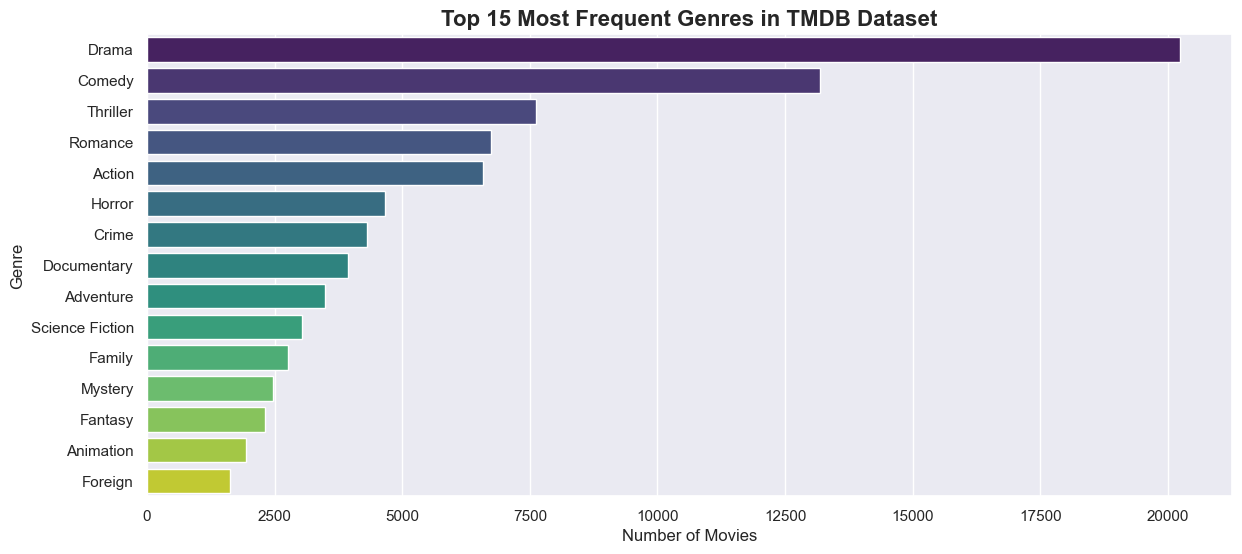

In [10]:
plt.figure(figsize=(14, 6))

# Flattening the list of genres
all_genres = [genre for sublist in eda_df['genres_list'].dropna() for genre in sublist]
genre_counts = pd.Series(all_genres).value_counts().head(15)

sns.barplot(x=genre_counts.values, y=genre_counts.index, palette="viridis")
plt.title('Top 15 Most Frequent Genres in TMDB Dataset', fontsize=16, fontweight='bold')
plt.xlabel('Number of Movies', fontsize=12)
plt.ylabel('Genre', fontsize=12)
plt.show()

### 6B. Plot Summary Text Density
Our cosine similarity matrix relies heavily on the `overview` column to match movies. If a large portion of our dataset has plot summaries that are only 5-10 words long, the vectorizer will struggle to find meaningful mathematical overlap. This histogram verifies that we have sufficient text mass to build a reliable content engine.

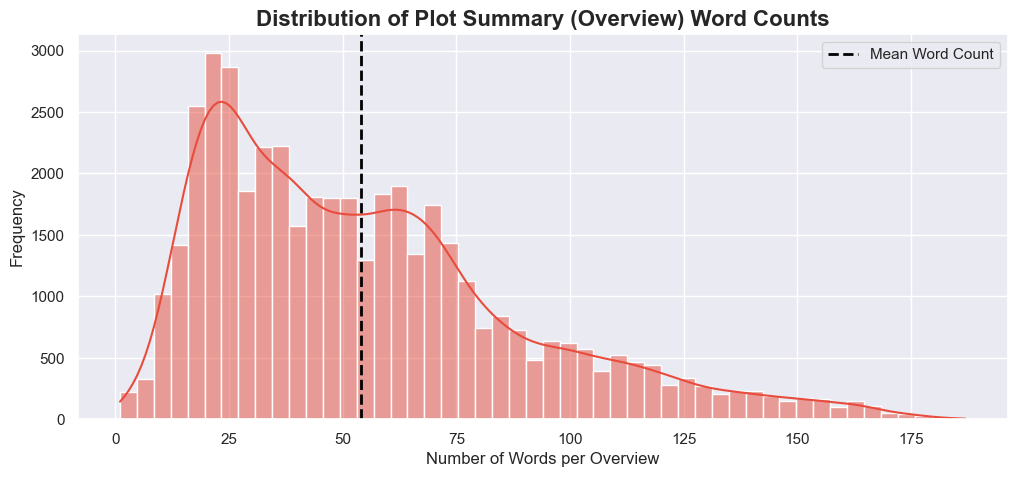

In [11]:
plt.figure(figsize=(12, 5))

# Calculating the word count for every movie overview
eda_df['overview_word_count'] = eda_df['overview'].fillna('').apply(lambda x: len(str(x).split()))

sns.histplot(eda_df[eda_df['overview_word_count'] > 0]['overview_word_count'], 
             bins=50, color='#e74c3c', kde=True)

plt.title('Distribution of Plot Summary (Overview) Word Counts', fontsize=16, fontweight='bold')
plt.xlabel('Number of Words per Overview', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.axvline(eda_df['overview_word_count'].mean(), color='black', linestyle='dashed', linewidth=2, label='Mean Word Count')
plt.legend()
plt.show()

### 6C. Temporal Distribution (Decade Spread)
Movie metadata often carries temporal stylistic markers (e.g., 1980s Sci-Fi reads differently than 2020s Sci-Fi). By visualizing the volume of movies per decade, we can identify any "modern bias" in the dataset. If the engine recommends predominantly modern movies, this chart helps explain that it is a reflection of the dataset's volume, not an algorithmic error.

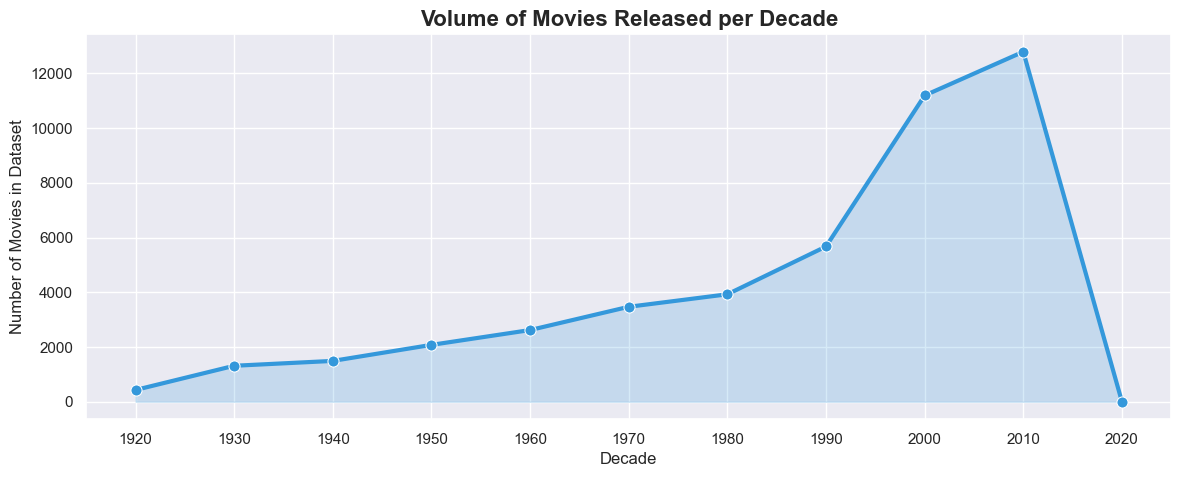

In [12]:
plt.figure(figsize=(14, 5))

eda_df['release_year'] = pd.to_datetime(eda_df['release_date'], errors='coerce').dt.year
eda_df['decade'] = (eda_df['release_year'] // 10) * 10

decade_counts = eda_df['decade'].value_counts().sort_index()

# Filtering out bad data (e.g., years < 1900 or future years)
decade_counts = decade_counts[(decade_counts.index >= 1920) & (decade_counts.index <= 2020)]

sns.lineplot(x=decade_counts.index.astype(int), y=decade_counts.values, 
             marker='o', color='#3498db', linewidth=3, markersize=8)

plt.title('Volume of Movies Released per Decade', fontsize=16, fontweight='bold')
plt.xlabel('Decade', fontsize=12)
plt.ylabel('Number of Movies in Dataset', fontsize=12)
plt.xticks(decade_counts.index.astype(int))
plt.fill_between(decade_counts.index.astype(int), decade_counts.values, alpha=0.2, color='#3498db')
plt.show()

### 6D. Quality vs. Popularity Bias
When a new user joins the platform (the "Cold Start" problem), we cannot rely on Collaborative Filtering, so we often fall back on sorting content-matches by `popularity` or `vote_average`. This scatter plot verifies whether those two metrics are essentially the same thing, or if they offer independent dimensions of movie quality to use in our final hybrid ranking logic.

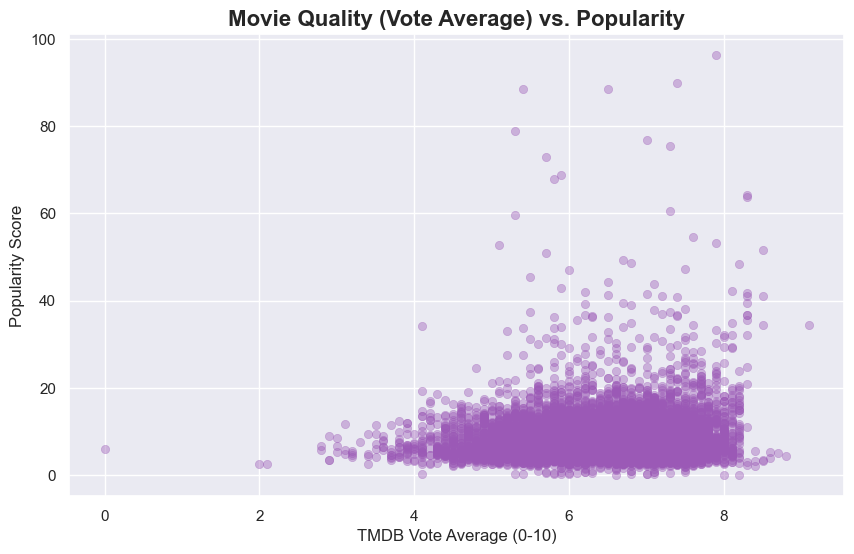

In [13]:
plt.figure(figsize=(10, 6))

# Converting to numeric, dropping bad data
eda_df['popularity'] = pd.to_numeric(eda_df['popularity'], errors='coerce')
eda_df['vote_average'] = pd.to_numeric(eda_df['vote_average'], errors='coerce')

# Filtering outliers for a cleaner scatter plot
scatter_df = eda_df[(eda_df['popularity'] < 100) & (eda_df['vote_count'] > 50)]

sns.scatterplot(data=scatter_df, x='vote_average', y='popularity', 
                alpha=0.4, color='#9b59b6', edgecolor=None)

plt.title('Movie Quality (Vote Average) vs. Popularity', fontsize=16, fontweight='bold')
plt.xlabel('TMDB Vote Average (0-10)', fontsize=12)
plt.ylabel('Popularity Score', fontsize=12)
plt.show()

## 7. Feature Engineering
Building a combined metadata text field for TF-IDF vectorization.

### 7.1 JSON-like Column Parsers

In [14]:
def safe_literal_eval(val: Any) -> Any:
    """Safely parse a JSON-like string using ast.literal_eval."""
    if isinstance(val, list):
        return val
    if pd.isna(val) or val == '':
        return []
    try:
        return ast.literal_eval(val)
    except (ValueError, SyntaxError):
        return []


def extract_names(obj_list: Any, key: str = 'name', max_items: Optional[int] = None) -> List[str]:
    """Extract 'name' values from a list of dicts."""
    parsed = safe_literal_eval(obj_list) if not isinstance(obj_list, list) else obj_list
    names = [item[key] for item in parsed if isinstance(item, dict) and key in item]
    if max_items:
        names = names[:max_items]
    return names


def get_director(crew_data: Any) -> str:
    """Extract director name from crew list."""
    parsed = safe_literal_eval(crew_data) if not isinstance(crew_data, list) else crew_data
    for member in parsed:
        if isinstance(member, dict) and member.get('job') == 'Director':
            return member.get('name', '')
    return ''


def normalize_name(name: str) -> str:
    """Lowercase and remove spaces: 'Tom Cruise' → 'tomcruise'."""
    return re.sub(r'\s+', '', name.lower().strip())


logger.info('Helper functions defined.')

16:45:38 | INFO     | Helper functions defined.


### 7.2 Applying Feature Extraction

In [15]:
# Parsing columns
logger.info('Parsing genres...')
df['genres_list'] = df['genres'].apply(lambda x: extract_names(x))
df['genres_str'] = df['genres_list'].apply(lambda x: ' '.join([normalize_name(g) for g in x]))

logger.info('Parsing keywords...')
df['keywords_list'] = df['keywords'].apply(lambda x: extract_names(x))
df['keywords_str'] = df['keywords_list'].apply(lambda x: ' '.join([normalize_name(k) for k in x]))

logger.info('Parsing cast (top 3)...')
df['cast_list'] = df['cast'].apply(lambda x: extract_names(x, max_items=TOP_CAST_COUNT))
df['cast_str'] = df['cast_list'].apply(lambda x: ' '.join([normalize_name(c) for c in x]))

logger.info('Parsing director...')
df['director'] = df['crew'].apply(get_director)
df['director_str'] = df['director'].apply(normalize_name)

logger.info('Feature extraction complete.')

16:45:38 | INFO     | Parsing genres...
16:45:39 | INFO     | Parsing keywords...
16:45:40 | INFO     | Parsing cast (top 3)...
16:45:54 | INFO     | Parsing director...
16:46:04 | INFO     | Feature extraction complete.


### 7.3 Building Combined Metadata Field

In [16]:
def build_metadata_soup(row: pd.Series) -> str:
    """Combine all metadata into a single text string for TF-IDF."""
    parts = [
        str(row.get('title', '')).lower(),
        str(row.get('overview', '')).lower(),
        str(row.get('genres_str', '')),
        str(row.get('keywords_str', '')),
        str(row.get('cast_str', '')),
        str(row.get('director_str', '')),
        str(int(row.get('year', 0))) if row.get('year', 0) > 0 else ''
    ]
    return ' '.join(parts).strip()


df['metadata_soup'] = df.apply(build_metadata_soup, axis=1)

# Droping rows with empty soup
df = df[df['metadata_soup'].str.strip().astype(bool)].reset_index(drop=True)

logger.info(f'Final dataset shape: {df.shape}')
print('\n--- Sample metadata_soup ---')
print(df['metadata_soup'].iloc[0][:300])

16:46:05 | INFO     | Final dataset shape: (46493, 21)



--- Sample metadata_soup ---
toy story led by woody, andy's toys live happily in his room until andy's birthday brings buzz lightyear onto the scene. afraid of losing his place in andy's heart, woody plots against buzz. but when circumstances separate buzz and woody from their owner, the duo eventually learns to put aside their


## 8. TF-IDF Vectorization

In [17]:
tfidf = TfidfVectorizer(
    stop_words=TFIDF_STOP_WORDS,
    ngram_range=TFIDF_NGRAM_RANGE,
    min_df=TFIDF_MIN_DF,
    max_features=TFIDF_MAX_FEATURES,
    dtype=np.float32  # Save memory
)

logger.info('Fitting TF-IDF vectorizer...')
tfidf_matrix = tfidf.fit_transform(df['metadata_soup'])

print(f'TF-IDF matrix shape : {tfidf_matrix.shape}')
print(f'Vocabulary size     : {len(tfidf.vocabulary_)}')
print(f'Matrix density      : {tfidf_matrix.nnz / (tfidf_matrix.shape[0]*tfidf_matrix.shape[1]):.6f}')
logger.info('TF-IDF vectorization complete.')

16:46:05 | INFO     | Fitting TF-IDF vectorizer...
16:46:11 | INFO     | TF-IDF vectorization complete.


TF-IDF matrix shape : (46493, 20000)
Vocabulary size     : 20000
Matrix density      : 0.001730


## 9. Cosine Similarity Engine

> **Memory Note:** For very large datasets (100k+ movies), building the full N×N similarity 
> matrix is impractical. In that case, compute similarity on-the-fly for a single movie using 
> `linear_kernel(tfidf_matrix[idx], tfidf_matrix)` which returns a 1×N vector.  
> This notebook uses the on-the-fly approach for efficiency.

In [18]:
# Building a title → index mapping (lowercase for case-insensitive lookup)
df['title_lower'] = df['title'].str.lower().str.strip()
indices = pd.Series(df.index, index=df['title_lower'])

# Handling duplicate titles — keep first occurrence
indices = indices[~indices.index.duplicated(keep='first')]

logger.info(f'Index mapping built: {len(indices)} unique titles.')

16:46:11 | INFO     | Index mapping built: 42227 unique titles.


## 10. Recommendation Function

In [19]:
def get_trending_movies(dataframe: pd.DataFrame, top_n: int = 10) -> pd.DataFrame:
    """Return trending movies by weighted popularity + vote_average (cold start fallback)."""
    temp = dataframe.copy()
    C = temp['vote_average'].mean()
    m = temp['vote_count'].quantile(0.70)
    qualified = temp[temp['vote_count'] >= m].copy()
    qualified['weighted_score'] = (
        (qualified['vote_count'] / (qualified['vote_count'] + m)) * qualified['vote_average']
        + (m / (qualified['vote_count'] + m)) * C
    )
    qualified = qualified.sort_values('weighted_score', ascending=False)
    cols = ['title', 'year', 'genres_str', 'vote_average', 'popularity', 'weighted_score']
    return qualified[cols].head(top_n).reset_index(drop=True)


def explain_match(query_soup: str, candidate_soup: str, top_terms: int = 6) -> str:
    """Generate a simple explainability string showing shared terms."""
    q_tokens = set(query_soup.lower().split())
    c_tokens = set(candidate_soup.lower().split())
    common = q_tokens & c_tokens
    # Filtering out very short or generic tokens
    common = sorted([t for t in common if len(t) > 2], key=lambda x: -len(x))
    return ', '.join(common[:top_terms]) if common else 'general thematic similarity'


def recommend_movies(
    title: str,
    top_n: int = DEFAULT_TOP_N,
    show_explanation: bool = True
) -> pd.DataFrame:
    """
    Recommend movies similar to the given title.

    Features:
      - Case-insensitive title matching
      - Fuzzy suggestion if exact title not found
      - Cold-start fallback to trending movies
      - Explainability output showing why each movie matched

    Parameters
    ----------
    title : str
        Movie title to find recommendations for.
    top_n : int
        Number of recommendations to return.
    show_explanation : bool
        Whether to include match explanations.

    Returns
    -------
    pd.DataFrame
        Recommendations with title, year, score, genres, vote_average, popularity.
    """
    title_clean = title.lower().strip()

    # ── Exact match ──
    if title_clean not in indices:
        # ── Fuzzy match ──
        close = get_close_matches(title_clean, indices.index.tolist(), n=5, cutoff=0.6)
        if close:
            print(f'"{title}" not found. Did you mean one of these?')
            for c in close:
                print(f'   → {c.title()}')
            # Auto-select best fuzzy match
            title_clean = close[0]
            print(f'\n Auto-selecting: "{title_clean.title()}"\n')
        else:
            print(f'"{title}" not found and no close matches.')
            print('Showing trending movies instead (Cold Start Fallback):\n')
            return get_trending_movies(df, top_n)

    idx = indices[title_clean]

    # ── Compute similarity on-the-fly (memory efficient) ──
    sim_scores = linear_kernel(tfidf_matrix[idx:idx+1], tfidf_matrix).flatten()
    # Get top indices (exclude self)
    top_indices = sim_scores.argsort()[::-1][1:top_n+1]

    results = []
    query_soup = df.iloc[idx]['metadata_soup']
    for i in top_indices:
        row = df.iloc[i]
        rec = {
            'title': row['title'],
            'year': int(row['year']),
            'score': round(float(sim_scores[i]), 4),
            'genres': row['genres_str'],
            'vote_average': row['vote_average'],
            'popularity': round(float(row['popularity']), 2)
        }
        if show_explanation:
            rec['matched_on'] = explain_match(query_soup, row['metadata_soup'])
        results.append(rec)

    result_df = pd.DataFrame(results)
    print(f'Top {top_n} recommendations for: "{title_clean.title()}"\n')
    return result_df


logger.info('Recommendation functions ready.')

16:46:11 | INFO     | Recommendation functions ready.


## 11. Evaluation / Demonstration
Showing recommendations for sample movies.

In [20]:
display(recommend_movies('Avatar', top_n=10))

Top 10 recommendations for: "Avatar"



,title,year,score,genres,vote_average,popularity,matched_on
0,Avatar 2,2020,0.3944,action adventure fantasy sciencefiction,0.0,6.02,"sciencefiction, samworthington, jamescameron, alienplane..."
1,Prince of Space,1959,0.2115,action sciencefiction,1.9,0.34,"sciencefiction, action, space, alien"
2,Welcome to the Space Show,2010,0.2012,animation sciencefiction,6.2,1.65,"sciencefiction, space, alien, moon, the, and"
3,Mission Blue,2014,0.1730,documentary,7.7,0.66,"jamescameron, marine, and"
4,Stand by Me Doraemon,2014,0.1716,fantasy animation family,7.0,6.49,"century,, fantasy, 22nd, the, and"
5,The Marine 2,2009,0.1703,action adventure drama thriller,4.7,8.14,"adventure, action, marine, 2009, the, and"
6,Project Moon Base,1953,0.1695,sciencefiction,2.5,0.48,"sciencefiction, spacetravel, future, moon, the"
7,Star Trek Into Darkness,2013,0.1681,action adventure sciencefiction,7.4,15.78,"sciencefiction, futuristic, zoesaldana, adventure, actio..."
8,Horror of the Blood Monsters,1970,0.1627,action horror sciencefiction,2.2,0.70,"sciencefiction, spacetravel, action, space, alien, the"
9,Dead Sea,2014,0.1587,thriller action sciencefiction horror,2.4,0.97,"sciencefiction, action, marine, the"


In [21]:
display(recommend_movies('The Dark Knight', top_n=10))

Top 10 recommendations for: "The Dark Knight"



,title,year,score,genres,vote_average,popularity,matched_on
0,The Dark Knight Rises,2012,0.4287,action crime drama thriller,7.6,20.58,"christophernolan, secretidentity, christianbale, michael..."
1,Batman: Under the Red Hood,2010,0.3668,action animation,7.6,7.04,"organizedcrime, basedoncomic, superpowers, vigilante, su..."
2,Batman Beyond: Return of the Joker,2000,0.3524,animation family,7.5,7.87,"superpowers, superhero, dccomics, batman, knight, crime."
3,Batman Returns,1992,0.3484,action fantasy,6.6,15.00,"crimefighter, supervillain, superpowers, gothamcity, vig..."
4,"Batman: The Dark Knight Returns, Part 2",2013,0.3443,action animation,7.9,12.58,"superpowers, dccomics, batman, action, knight, joker"
5,Batman Begins,2005,0.3405,action crime drama,7.5,28.51,"christophernolan, secretidentity, christianbale, basedon..."
6,Batman Unmasked: The Psychology of the Dark Knight,2008,0.3404,documentary,8.0,1.08,"superpowers, vigilante, batman, knight, that, 2008"
7,Batman,1989,0.3360,fantasy action,7.0,19.11,"crimefighter, superpowers, gothamcity, superhero, dccomi..."
8,Batman: The Killing Joke,2016,0.3342,action animation crime drama,6.2,6.49,"basedoncomic, superpowers, superhero, dccomics, action, ..."
9,Batman Beyond Darwyn Cooke's Batman 75th Anniversary Short,2014,0.3318,action animation sciencefiction,7.7,0.85,"basedoncomic, superhero, dccomics, batman, action"


In [22]:
display(recommend_movies('Toy Story', top_n=10))

Top 10 recommendations for: "Toy Story"



,title,year,score,genres,vote_average,popularity,matched_on
0,Toy Story 2,1999,0.5223,animation comedy family,7.3,17.55,"toycomestolife, johnlasseter, friendship, lightyear, ani..."
1,Toy Story 3,2010,0.5219,animation family comedy,7.6,16.97,"toycomestolife, animation, timallen, tomhanks, family, a..."
2,Small Fry,2011,0.2977,animation family,6.8,9.86,"animation, timallen, friends, family, buzz, toys"
3,The Champ,1931,0.2488,drama,6.8,1.33,"place, their, when, but, the, and"
4,Toy Story of Terror!,2013,0.2412,animation comedy family,7.3,0.51,"animation, timallen, tomhanks, family, comedy, story"
5,Andy Hardy's Blonde Trouble,1944,0.2349,comedy family romance,6.3,0.51,"family, comedy, their, when, but, the"
6,The 40 Year Old Virgin,2005,0.2308,comedy romance,6.2,11.52,"comedy, until, their, but, the, and"
7,Andy Kaufman Plays Carnegie Hall,1980,0.2229,,0.0,0.05,"family, andy's, from, the, and"
8,Toy Reanimator,2002,0.2174,sciencefiction fantasy,0.0,0.00,"toy, the, and, boy"
9,Hot Splash,1988,0.2098,,4.0,0.04,"their, woody, but, and"


In [23]:
display(recommend_movies('Titanic', top_n=10))

Top 10 recommendations for: "Titanic"



,title,year,score,genres,vote_average,popularity,matched_on
0,Drain the Titanic,2016,0.3917,documentary,0.0,0.04,"titanic, the"
1,Titanic: The Final Word with James Cameron,2012,0.3635,documentary history,6.6,0.55,"jamescameron, titanic, with, ship, the, and"
2,Titanic,1953,0.3313,drama action romance,6.2,12.91,"titanic, romance, drama, with, ship, the"
3,Raise the Titanic,1980,0.3235,action drama thriller,5.2,2.13,"thriller, titanic, drama, ship, the"
4,Titanic 2,2010,0.2891,action adventure thriller,3.4,4.36,"passengers, thriller, titanic, when, the, and"
5,A Night to Remember,1958,0.2744,drama action history,7.5,6.56,"passengers, disaster, titanic, iceberg, about, drama"
6,Titanica,1995,0.2642,documentary,6.0,0.83,"shipwreck, titanic, iceberg, april, tells, 1912,"
7,Titanic,1996,0.2622,action drama romance,6.3,3.44,"oceanliner, meanwhile,, shipwreck, disaster, titanic, ro..."
8,Doctor Who: Voyage of the Damned,2007,0.2602,sciencefiction,8.0,1.65,"disaster, titanic, voyage, friend, called, whole"
9,Titanic at 100: Mystery Solved,2012,0.2444,,8.0,0.05,"titanic, ship, the, and"


## 12. Cold Start Handling Demo

In [24]:
# Movie that doesn't exist — triggers cold start fallback
display(recommend_movies('NonExistentMovie12345', top_n=10))

"NonExistentMovie12345" not found and no close matches.
Showing trending movies instead (Cold Start Fallback):



,title,year,genres_str,vote_average,popularity,weighted_score
0,Dilwale Dulhania Le Jayenge,1995,comedy drama romance,9.1,34.457024,8.972881
1,The Shawshank Redemption,1994,drama crime,8.5,51.645403,8.491387
2,The Godfather,1972,drama crime,8.5,41.109264,8.488064
3,Your Name.,2016,romance animation drama,8.5,34.461252,8.431561
4,Planet Earth,2006,documentary,8.8,4.501137,8.403465
5,The Dark Knight,2008,drama action crime thriller,8.3,123.167259,8.294534
6,Fight Club,1999,drama,8.3,63.869599,8.293074
7,Pulp Fiction,1994,thriller crime,8.3,140.950236,8.292271
8,Schindler's List,1993,drama history war,8.3,41.725123,8.284935
9,Whiplash,2014,drama,8.3,64.299990,8.284730


## 13. Interactive Lookup (CLI-like)

In [25]:
movie_name = "Inception"

display(recommend_movies(movie_name, top_n=10, show_explanation=True))

Top 10 recommendations for: "Inception"



,title,year,score,genres,vote_average,popularity,matched_on
0,Don Jon,2013,0.2023,romance comedy drama,5.9,10.95,"josephgordon-levitt, his"
1,Elektra Luxx,2010,0.1850,action comedy drama,4.7,4.12,"josephgordon-levitt, action, into, 2010, life, the"
2,Hesher,2010,0.1705,drama,6.7,5.89,"josephgordon-levitt, 2010, life, the, who, his"
3,Snowden,2016,0.1633,drama thriller,7.0,14.38,"josephgordon-levitt, thriller, the"
4,Looper,2012,0.1566,action thriller sciencefiction,6.6,12.73,"josephgordon-levitt, sciencefiction, thriller, action, i..."
5,Premium Rush,2012,0.1469,crime action thriller,6.2,5.65,"josephgordon-levitt, thriller, action, the, who"
6,The Walk,2015,0.1464,adventure drama thriller,6.9,9.43,"josephgordon-levitt, adventure, thriller, the"
7,Brick,2005,0.1447,drama mystery,6.8,9.00,"josephgordon-levitt, mystery, into, the, his"
8,Cypher,2002,0.1440,thriller sciencefiction mystery,6.7,7.35,"sciencefiction, corporate, espionage, thriller, mystery,..."
9,Gamer,2001,0.1429,action thriller sciencefiction foreign,3.2,0.76,"sciencefiction, thriller, action"


## 14. Save Trained Artifacts
Persist all assets for downstream use in the hybrid pipeline.

In [27]:
current_folder = os.getcwd()
parent_folder = os.path.dirname(current_folder)

dynamic_path = os.path.join(parent_folder, 'artifacts')
ARTIFACT_DIR = os.path.abspath(dynamic_path)

os.makedirs(ARTIFACT_DIR, exist_ok=True)

print(f"Targeting dynamic artifact directory: {ARTIFACT_DIR}")

try:
    # Save TF-IDF vectorizer
    joblib.dump(tfidf, os.path.join(ARTIFACT_DIR, 'tfidf_vectorizer.pkl'))
    logger.info('Saved tfidf_vectorizer.pkl')

    # Save TF-IDF matrix
    joblib.dump(tfidf_matrix, os.path.join(ARTIFACT_DIR, 'tfidf_matrix.pkl'))
    logger.info('Saved tfidf_matrix.pkl')

    # Save movie indices mapping
    joblib.dump(indices, os.path.join(ARTIFACT_DIR, 'movie_indices.pkl'))
    logger.info('Saved movie_indices.pkl')

    # Savinhg the processed dataframe as the content model
    model_cols = ['id', 'title', 'title_lower', 'year', 'overview', 'genres_str',
                  'keywords_str', 'cast_str', 'director_str', 'metadata_soup',
                  'vote_average', 'vote_count', 'popularity']
    df_model = df[model_cols].copy()
    joblib.dump(df_model, os.path.join(ARTIFACT_DIR, 'movies_content_model.pkl'))
    logger.info('Saved movies_content_model.pkl')

    print('\n All artifacts saved successfully to:', ARTIFACT_DIR)
    for f in os.listdir(ARTIFACT_DIR):
        fpath = os.path.join(ARTIFACT_DIR, f)
        size_mb = os.path.getsize(fpath) / (1024*1024)
        print(f'    {f:35s} — {size_mb:.2f} MB')

except Exception as e:
    logger.error(f'Failed to save artifacts: {e}')
    raise

Targeting dynamic artifact directory: c:\Users\icehe\Downloads\Cineiq\artifacts


16:48:32 | INFO     | Saved tfidf_vectorizer.pkl
16:48:32 | INFO     | Saved tfidf_matrix.pkl
16:48:32 | INFO     | Saved movie_indices.pkl
16:48:32 | INFO     | Saved movies_content_model.pkl



 All artifacts saved successfully to: c:\Users\icehe\Downloads\Cineiq\artifacts
    experiment_log.json                 — 0.00 MB
    mappings.json                       — 2.99 MB
    movies_content_model.pkl            — 41.60 MB
    movie_indices.pkl                   — 2.27 MB
    svd_model.pkl                       — 757.77 MB
    tfidf_matrix.pkl                    — 12.45 MB
    tfidf_vectorizer.pkl                — 0.59 MB
